In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [3]:
data = pd.read_csv('Advertising.csv', usecols=["TV","Radio","Newspaper","Sales"])
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


#### Getting the columns for the features and the response

In [6]:
colPredictors = data.columns[:-1]
colResponse = data.columns[-1]

In [7]:
totalSamples = data.shape[0]
totalSamples

200

Spliting into training and test set

In [8]:
permuted_array = np.random.permutation( 200 )
idx_train = int( 200*.7)

dataTrain = data.iloc[permuted_array[:idx_train ] ]
dataTest = data.iloc[permuted_array[idx_train: ] ]
# reset index
dataTrain.reset_index(drop=True, inplace=True)
dataTest.reset_index(drop=True, inplace=True)

In [9]:
dataTrain.head()

,TV,Radio,Newspaper,Sales
0,228.0,37.7,32.0,21.5
1,89.7,9.9,35.7,10.6
2,177.0,9.3,6.4,12.8
3,38.0,40.3,11.9,10.9
4,140.3,1.9,9.0,10.3


# LEAST SQUARE SOLUTION

Adding a column of ones.

In [10]:
X_extended = np.hstack( [ np.ones( [dataTrain[colPredictors].shape[0], 1] ), dataTrain[colPredictors] ] )


In [11]:
X_extended[:10] #printing first 10 rows

array([[  1. , 228. ,  37.7,  32. ],
       [  1. ,  89.7,   9.9,  35.7],
       [  1. , 177. ,   9.3,   6.4],
       [  1. ,  38. ,  40.3,  11.9],
       [  1. , 140.3,   1.9,   9. ],
       [  1. , 139.2,  14.3,  25.6],
       [  1. ,  31.5,  24.6,   2.2],
       [  1. , 191.1,  28.7,  18.2],
       [  1. ,  38.2,   3.7,  13.8],
       [  1. , 248.4,  30.2,  20.3]])

In [12]:
sol = np.linalg.inv(X_extended.T@X_extended)@X_extended.T @ dataTrain[colResponse]

var_names = ['bias', 'TV', 'Radio', 'Newspaer']

for v, c in zip(var_names, sol):
    print(f'coef for {v} is {c}')

coef for bias is 3.153452496417483
coef for TV is 0.044710028519219645
coef for Radio is 0.1845495459832106
coef for Newspaer is -0.0015318833996235057


In [13]:
exog = sm.add_constant(dataTrain[colPredictors] )
mod = sm.OLS(dataTrain[colResponse], exog)

res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     348.6
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.24e-63
Time:                        18:38:24   Log-Likelihood:                -274.41
No. Observations:                 140   AIC:                             556.8
Df Residuals:                     136   BIC:                             568.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1535      0.392      8.049      0.0

In [14]:
yHat = res.predict( exog)

# Checking residuals 

Text(0.5, 0, 'Fitted values')

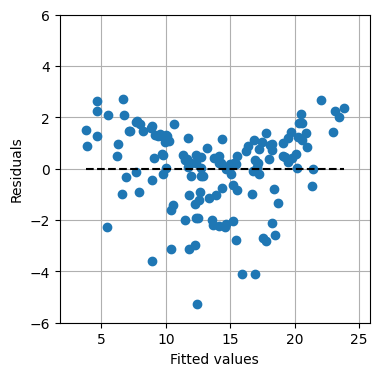

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.plot( yHat, dataTrain[colResponse] - yHat, 'o' )
plt.plot( [np.min(yHat), np.max(yHat) ] , [0, 0], 'k--')
plt.xlim(np.min(yHat)-2, np.max(yHat)+2)
plt.ylim(-6, 6)   # adjust if needed
plt.grid()
plt.ylabel('Residuals')
plt.xlabel('Fitted values')

Previous plot shows a little of pattern, which may suggest that linear regression is not fully appropriate for this data due to possible nonlinearity.

# Combined effect

In [16]:
joined =  dataTrain[colPredictors].copy()
joined['tv*radio'] = dataTrain[colPredictors[0]]*dataTrain[colPredictors[1] ]

exog = sm.add_constant( joined  )
mod = sm.OLS(dataTrain[colResponse], exog)

res_c = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     348.6
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.24e-63
Time:                        18:38:47   Log-Likelihood:                -274.41
No. Observations:                 140   AIC:                             556.8
Df Residuals:                     136   BIC:                             568.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1535      0.392      8.049      0.0

Text(0.5, 0, 'Fitted values')

<Figure size 400x400 with 0 Axes>

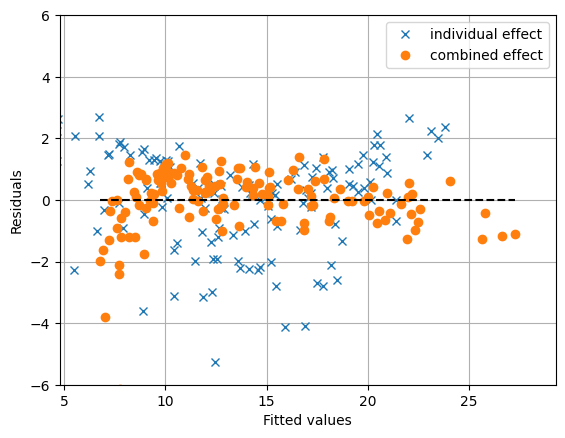

In [17]:
plt.figure(figsize=(4,4))
yHat_combined = res_c.predict( exog)
plt.figure()
plt.plot( yHat, dataTrain[colResponse] - yHat, 'x', label='individual effect' )
plt.plot( yHat_combined, dataTrain[colResponse] - yHat_combined, 'o', label='combined effect'  )
plt.plot( [np.min(yHat_combined), np.max(yHat_combined) ] , [0, 0], 'k--')
plt.xlim(np.min(yHat_combined)-2, np.max(yHat_combined)+2)
plt.ylim(-6, 6)   # adjust if needed
plt.grid()
plt.legend()
plt.ylabel('Residuals')
plt.xlabel('Fitted values')




Checking on the test data

In [18]:
exog_test = sm.add_constant(dataTest[colPredictors] )

joined_test =  dataTest[colPredictors].copy()
joined_test['tv*radio'] = dataTest[colPredictors[0]]*dataTest[colPredictors[1] ]
joined_test = sm.add_constant( joined_test  )

yHat =  res.predict( exog_test)
yHat_combined =  res_c.predict( joined_test )

Text(0.5, 0, 'Fitted values')

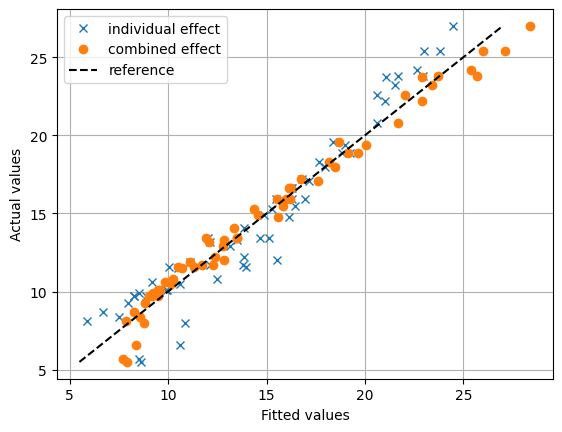

In [19]:
plt.figure()
plt.plot( yHat, dataTest[colResponse]  , 'x', label='individual effect' )
plt.plot( yHat_combined, dataTest[colResponse], 'o', label='combined effect'  )
plt.plot( [np.min(dataTest[colResponse]), np.max(dataTest[colResponse]) ] , 
         [np.min(dataTest[colResponse]), np.max(dataTest[colResponse]) ],'k--', label='reference'  )
plt.grid()
plt.legend()
plt.ylabel('Actual values')
plt.xlabel('Fitted values')


# Robust Regression - HuberRegressor

Huber Regressor give preference to the data points which are inliers. This again helps to learn the patterns specifically instead of the noise present in the data. In other words, ignore data outliers.

We can use the in-built Python fuction to calculate it: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html 

In [21]:
from sklearn.linear_model import HuberRegressor, LinearRegression

#Let's create a linear regressor
linear = LinearRegression()
# Fit the regression
linear.fit( dataTrain[colPredictors], dataTrain[colResponse] )

# print the coefficients
print( linear.intercept_, linear.coef_)



3.1534524964174953 [ 0.04471003  0.18454955 -0.00153188]


We can use ''score'' to calculate the $R^2$



```python
score(X, y, sample_weight=None):
Return the coefficient of determination of the prediction.

The coefficient of determination is defined as:

    R^2 = 1 - (SS_res / SS_tot)

where:
    SS_res = ((y_true - y_pred) ** 2).sum()
    SS_tot = ((y_true - y_true.mean()) ** 2).sum()

The best possible score is 1.0, but it can be negative (indicating the model performs worse than a constant model). 
A constant model that always predicts the expected value of y, regardless of the input features, 
would achieve an R^2 score of 0.0.
```

In [22]:
R2 = linear.score(dataTrain[colPredictors], dataTrain[colResponse] )

print(f'R2 for linear is {R2}')

R2 for linear is 0.8849151816528695


For Huber regresison

In [23]:
# Huber regressor
huber = HuberRegressor(epsilon=1)
huber.fit( dataTrain[colPredictors], dataTrain[colResponse] )

# print the coefficients
print('Coefficients')
print( huber.intercept_, huber.coef_)



# print the coefficients
print('R2')
huber.score(data[colPredictors], data[colResponse] )

Coefficients
3.4009347937577443 [ 0.04320287  0.19731937 -0.00110269]
R2


0.891868259307212

Let's make predictions

In [24]:
linear_predictions = linear.predict( dataTest[colPredictors] ) 
huber_predictions = huber.predict( dataTest[colPredictors] ) 

Text(0.5, 0, 'Fitted values')

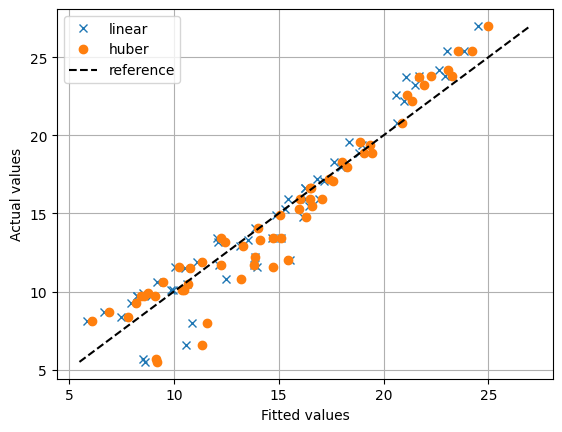

In [25]:
plt.figure()
plt.plot( linear_predictions, dataTest[colResponse]  , 'x', label='linear' )
plt.plot( huber_predictions, dataTest[colResponse], 'o', label='huber'  )
plt.plot( [np.min(dataTest[colResponse]), np.max(dataTest[colResponse]) ] , 
         [np.min(dataTest[colResponse]), np.max(dataTest[colResponse]) ],'k--', label='reference'  )
plt.grid()
plt.legend()
plt.ylabel('Actual values')
plt.xlabel('Fitted values')

Text(0, 0.5, 'Residuals')

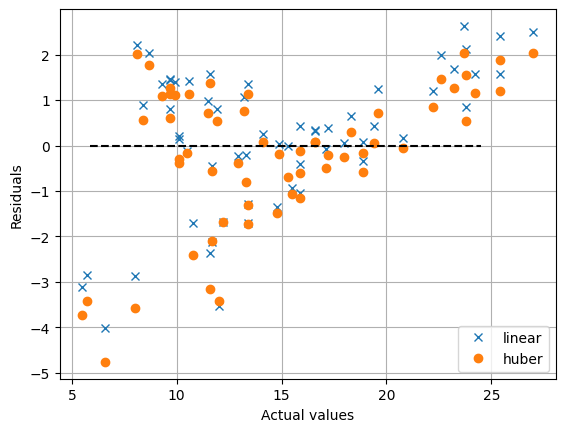

In [26]:
plt.figure()
plt.plot( dataTest[colResponse], dataTest[colResponse]-linear_predictions  , 'x', label='linear' )
plt.plot( dataTest[colResponse], dataTest[colResponse]-huber_predictions, 'o', label='huber'  )
plt.plot( [np.min(linear_predictions), np.max(linear_predictions) ] , [0, 0], 'k--')
plt.grid()
plt.legend()
plt.xlabel('Actual values')
plt.ylabel('Residuals')

We can also use:
* Laso
* Elastic NEt
* Ridge

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

3.1534524964174953 [ 0.04471003  0.18454955 -0.00153188]


Text(0, 0.5, 'Residuals')

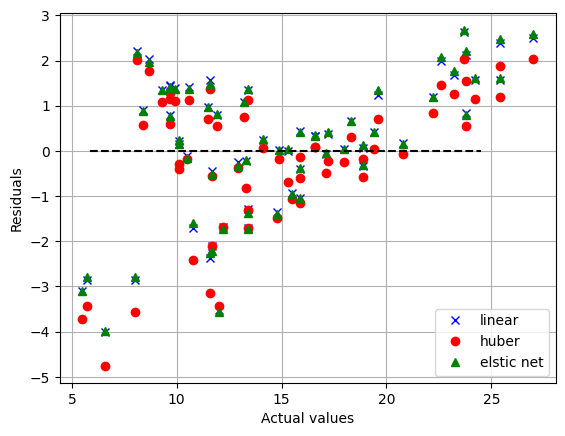

In [27]:
from sklearn.linear_model import ElasticNet
regr = ElasticNet(random_state=0, max_iter=1000)

regr.fit( dataTrain[colPredictors], dataTrain[colResponse] )

# print the coefficients
print( linear.intercept_, linear.coef_)

elastic_predictions = regr.predict( dataTest[colPredictors] )

plt.figure()
plt.plot( dataTest[colResponse], dataTest[colResponse]-linear_predictions  , 'bx', label='linear' )
plt.plot( dataTest[colResponse], dataTest[colResponse]-huber_predictions, 'ro', label='huber'  )
plt.plot( dataTest[colResponse], dataTest[colResponse]-elastic_predictions, 'g^', label='elstic net'  )
plt.plot( [np.min(linear_predictions), np.max(linear_predictions) ] , [0, 0], 'k--')
plt.grid()
plt.legend()
plt.xlabel('Actual values')
plt.ylabel('Residuals')

## How we can do cross validation here for the elastic net?

In [28]:
permuted_array = np.random.permutation( dataTrain.shape[0] )
idx_train = int( dataTrain.shape[0]*.7)

dataTrainVal = dataTrain.iloc[permuted_array[:idx_train ] ]
dataVal = dataTrain.iloc[permuted_array[idx_train: ] ]
# reset index
dataTrainVal.reset_index(drop=True, inplace=True)
dataVal.reset_index(drop=True, inplace=True)

In [29]:
alphas = np.logspace(-10,5,20)
ratios = np.linspace(0.05, 0.95, 20)

best_alpha = -1
best_ratio = -1



best_training = 1000
for alpha_candidate in alphas:
    for ratio_candidate in ratios:
        regr = ElasticNet(random_state=0, alpha=alpha_candidate, 
                          l1_ratio=ratio_candidate, max_iter=1000)

        regr.fit( dataTrainVal[colPredictors], dataTrainVal[colResponse] )

        elastic_predictionsVal = regr.predict( dataVal[colPredictors] )

        mse = np.sum( (dataVal[colResponse] - elastic_predictionsVal )**2 ) 

        # print(f" mse {mse} alpha:{alpha_candidate}  ratio:{ratio_candidate}")

        if mse < best_training:
            best_training = mse
            best_alpha = alpha_candidate
            best_ratio = ratio_candidate
            

print(f"best alpha:{best_alpha} best ratio:{best_ratio}")




best alpha:1e-10 best ratio:0.05


Text(0, 0.5, 'Residuals')

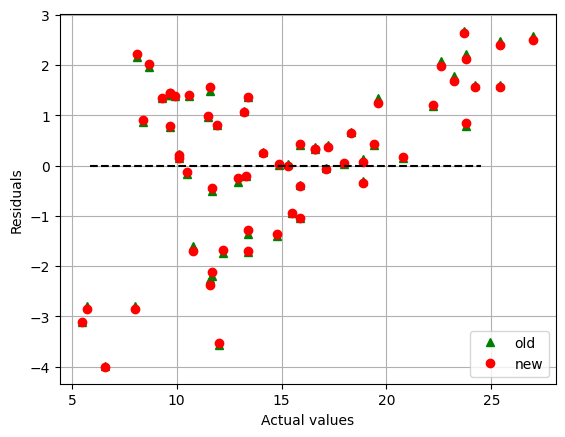

In [30]:
regr2 = ElasticNet(random_state=0, alpha=best_alpha, l1_ratio=best_ratio, max_iter=1000)

regr2.fit( dataTrain[colPredictors], dataTrain[colResponse] )



elastic_predictions2 = regr2.predict( dataTest[colPredictors] )

plt.figure()
plt.plot( dataTest[colResponse], dataTest[colResponse]-elastic_predictions, 'g^', label='old'  )
plt.plot( dataTest[colResponse], dataTest[colResponse]-elastic_predictions2, 'ro', label='new'  )
plt.plot( [np.min(linear_predictions), np.max(linear_predictions) ] , [0, 0], 'k--')
plt.grid()
plt.legend()
plt.xlabel('Actual values')
plt.ylabel('Residuals')